In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

2025-05-20 17:42:08.267892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747762928.516773      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747762928.585619      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df = pd.read_csv("/kaggle/input/dataset-preguntassimilares/preguntas.csv")

MAX_VOCAB_SIZE = 20000 
MAX_SEQUENCE_LENGTH = 50

vectorizer = tf.keras.layers.TextVectorization(max_tokens=MAX_VOCAB_SIZE, output_sequence_length=MAX_SEQUENCE_LENGTH)
vectorizer.adapt(df['question1'].tolist() + df['question2'].tolist())

q1_seq = vectorizer(df['question1'].tolist()).numpy()
q2_seq = vectorizer(df['question2'].tolist()).numpy()

y = df['is_duplicate'].values
q1_train, q1_test, q2_train, q2_test, y_train, y_test = train_test_split(q1_seq, q2_seq, y, test_size=0.2, random_state=42)

EMBEDDING_DIM = 100

I0000 00:00:1747762949.948122      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747762949.948864      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [4]:
history = model.fit([q1_train, q2_train], y_train, batch_size=128, epochs=10, validation_data=([q1_test, q2_test], y_test))

Epoch 1/10


I0000 00:00:1747762968.060919      92 cuda_dnn.cc:529] Loaded cuDNN version 90300


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6291 - loss: 0.6618 - val_accuracy: 0.6926 - val_loss: 0.5760
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7288 - loss: 0.5457 - val_accuracy: 0.7420 - val_loss: 0.5168
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7641 - loss: 0.4866 - val_accuracy: 0.7462 - val_loss: 0.5152
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7879 - loss: 0.4509 - val_accuracy: 0.7528 - val_loss: 0.5135
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8099 - loss: 0.4143 - val_accuracy: 0.7555 - val_loss: 0.5194
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8280 - loss: 0.3806 - val_accuracy: 0.7505 - val_loss: 0.5447
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8444 - loss: 0.3510 - val_accuracy: 0.7518 - val_loss: 0.5772
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8584 - loss: 0.3209 - val

In [5]:
def plotLossAccuracy(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Evolución de la pérdida')
    plt.ylim(bottom=0)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Evolución de la precisión')
    plt.ylim(bottom=0)
    
    plt.show()

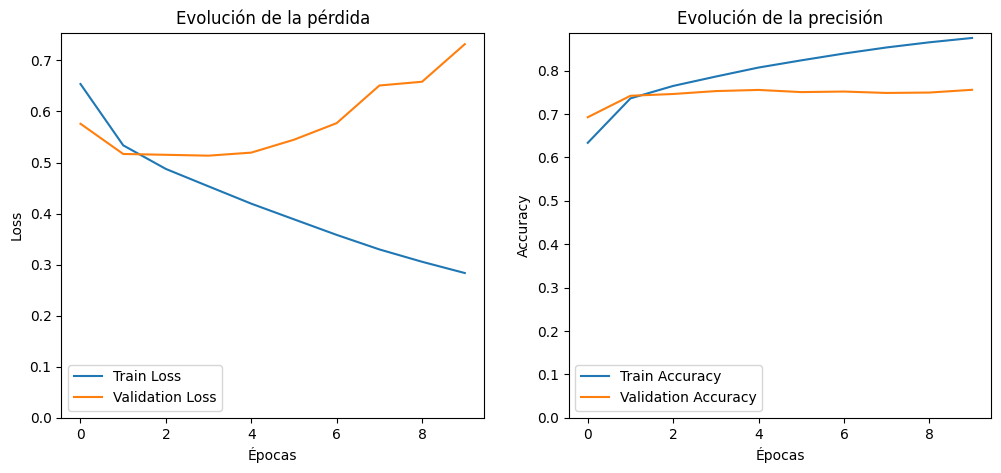

In [6]:
plotLossAccuracy(history)

In [7]:
def evaluateModel(model):
    y_pred = (model.predict([q1_test, q2_test]) > 0.5).astype(int)
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Duplicada', 'Duplicada'], yticklabels=['No Duplicada', 'Duplicada'])
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de confusión')
    plt.show()
    
    print("Informe de clasificación:")
    print(classification_report(y_test, y_pred, target_names=['No Duplicada', 'Duplicada']))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


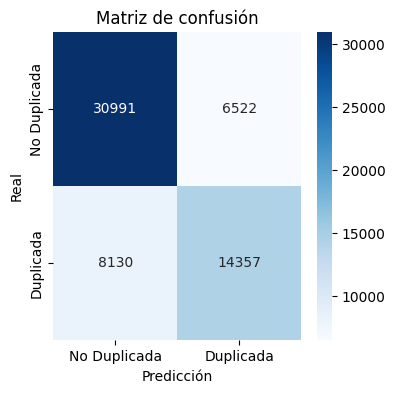

Informe de clasificación:
              precision    recall  f1-score   support

No Duplicada       0.79      0.83      0.81     37513
   Duplicada       0.69      0.64      0.66     22487

    accuracy                           0.76     60000
   macro avg       0.74      0.73      0.74     60000
weighted avg       0.75      0.76      0.75     60000



In [8]:
evaluateModel(model)

In [9]:
model2 = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history2 = model2.fit([q1_train, q2_train], y_train, batch_size=128, epochs=20, validation_data=([q1_test, q2_test], y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6746 - loss: 0.6074 - val_accuracy: 0.7423 - val_loss: 0.5207
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7589 - loss: 0.4992 - val_accuracy: 0.7445 - val_loss: 0.5129
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7748 - loss: 0.4699 - val_accuracy: 0.7509 - val_loss: 0.5229
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7965 - loss: 0.4354 - val_accuracy: 0.7528 - val_loss: 0.5170
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8145 - loss: 0.4036 - val_accuracy: 0.7534 - val_loss: 0.5415
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8327 - loss: 0.3719 - val_accuracy: 0.7545 - val_loss: 0.5699
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8480 - loss: 0.3431 - val_accuracy: 0.7510 - val_loss: 0.5943
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8612 - loss: 0

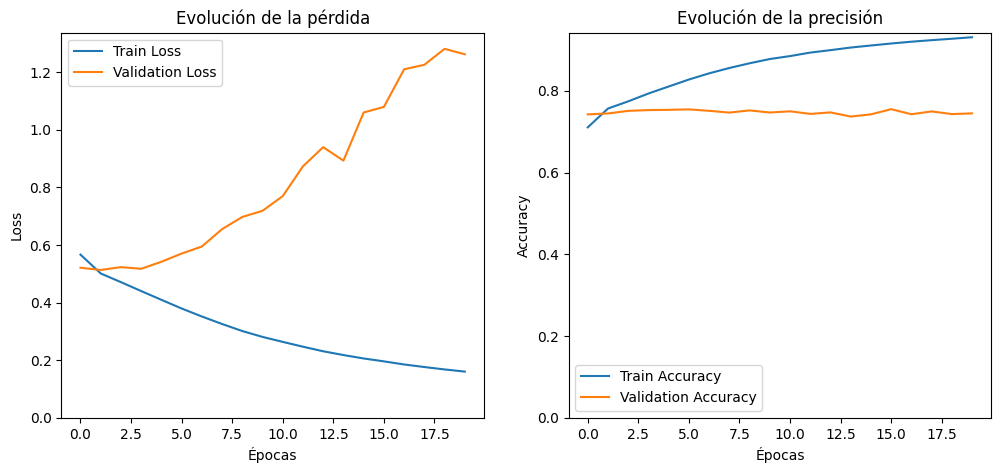

In [10]:
plotLossAccuracy(history2)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


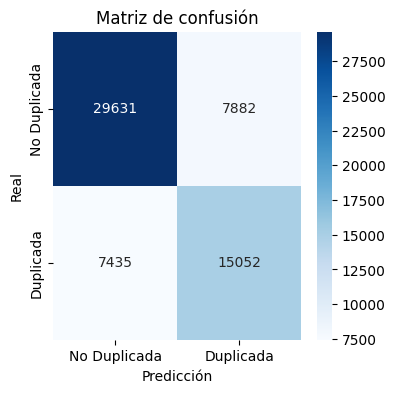

Informe de clasificación:
              precision    recall  f1-score   support

No Duplicada       0.80      0.79      0.79     37513
   Duplicada       0.66      0.67      0.66     22487

    accuracy                           0.74     60000
   macro avg       0.73      0.73      0.73     60000
weighted avg       0.75      0.74      0.75     60000



In [11]:
evaluateModel(model2)

In [12]:
model3 = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(32, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(16, dropout=0.3)),    
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2,verbose=1)

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history3 = model3.fit([q1_train, q2_train], y_train, batch_size=128, epochs=20, validation_data=([q1_test, q2_test], y_test),callbacks=[early_stop, reduce_lr])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.7035 - loss: 0.5698 - val_accuracy: 0.7409 - val_loss: 0.5201 - learning_rate: 0.0010
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7638 - loss: 0.4900 - val_accuracy: 0.7471 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7778 - loss: 0.4601 - val_accuracy: 0.7455 - val_loss: 0.5170 - learning_rate: 0.0010
Epoch 4/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7929 - loss: 0.4323
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7929 - loss: 0.4323 - val_accuracy: 0.7506 - val_loss: 0.5228 - learning_rate: 0.0010
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8086 - loss: 0.4015 - val_accuracy: 0.7457 - val_loss: 0.5501 - learning_rate: 5.0000e-04
Epoch 6/20
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accur

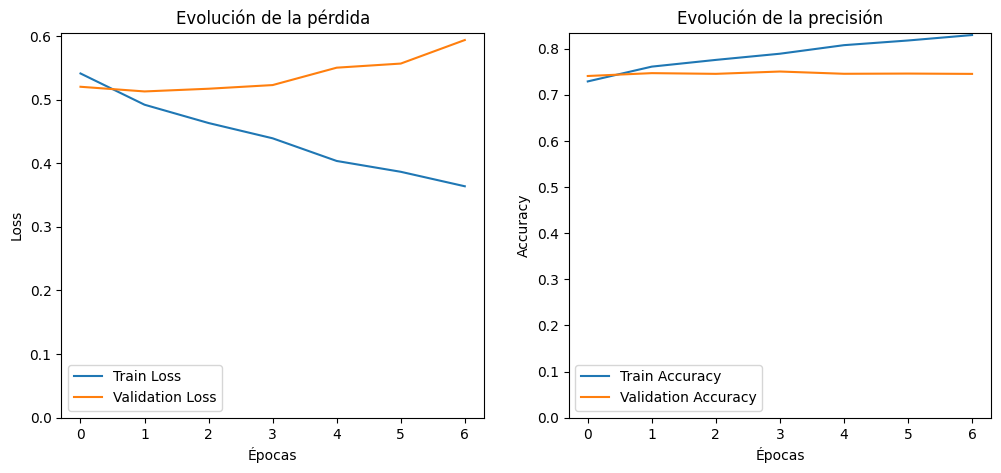

In [13]:
plotLossAccuracy(history3)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step


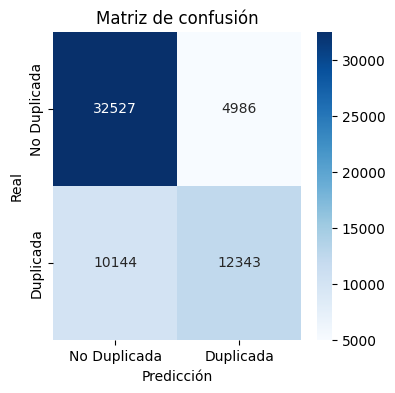

Informe de clasificación:
              precision    recall  f1-score   support

No Duplicada       0.76      0.87      0.81     37513
   Duplicada       0.71      0.55      0.62     22487

    accuracy                           0.75     60000
   macro avg       0.74      0.71      0.72     60000
weighted avg       0.74      0.75      0.74     60000



In [14]:
evaluateModel(model3)